# Bagging e redução de variância

**Tema:** Aprendizado Supervisionado › Bagging e Random Forest

Este notebook implementa bagging do zero, mede a redução de variância
diretamente (comparando árvores individuais com o ensemble), e confirma a
fórmula $\rho\sigma^2 + (1-\rho)\sigma^2/B$ do `teoria.pdf` simulando
ensembles com árvores mais e menos correlacionadas entre si.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(40)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Bagging do zero

In [2]:
def bagging_do_zero(X_treino, y_treino, X_novo, n_estimadores=100, seed=0):
    rng_local = np.random.default_rng(seed)
    n = len(X_treino)
    previsoes = np.zeros((n_estimadores, len(X_novo)))
    for b in range(n_estimadores):
        indices_bootstrap = rng_local.integers(0, n, n)
        arvore = DecisionTreeRegressor(random_state=b).fit(
            X_treino[indices_bootstrap], y_treino[indices_bootstrap])
        previsoes[b] = arvore.predict(X_novo)
    return previsoes.mean(axis=0), previsoes


x = np.linspace(0, 10, 300).reshape(-1, 1)
y_verdadeiro = np.sin(x.ravel()) * 3
y_treino_ruidoso = y_verdadeiro + rng.normal(0, 1.2, len(x))

pred_bagging, todas_previsoes = bagging_do_zero(x, y_treino_ruidoso, x, n_estimadores=100)
pred_sklearn = BaggingRegressor(
    DecisionTreeRegressor(), n_estimators=100, random_state=0).fit(
    x, y_treino_ruidoso).predict(x)

erro_manual = mean_squared_error(y_verdadeiro, pred_bagging)
erro_sklearn = mean_squared_error(y_verdadeiro, pred_sklearn)
print(f"MSE contra a função verdadeira (bagging manual) : {erro_manual:.4f}")
print(f"MSE contra a função verdadeira (sklearn)         : {erro_sklearn:.4f}")

MSE contra a função verdadeira (bagging manual) : 0.7502
MSE contra a função verdadeira (sklearn)         : 0.7313


## 2. Visualizando: árvores individuais (ruidosas) vs. a média (suave)

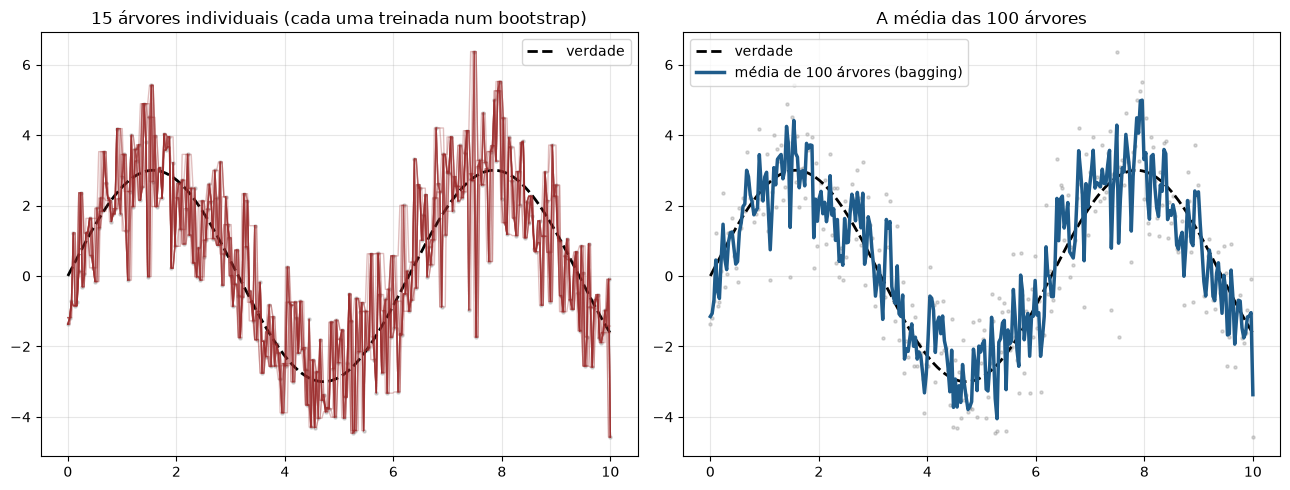

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(x, y_treino_ruidoso, s=5, alpha=0.3, color="gray")
axes[0].plot(x, y_verdadeiro, color="black", lw=2, ls="--", label="verdade")
for i in range(15):
    axes[0].plot(x, todas_previsoes[i], alpha=0.3, lw=1, color=VERMELHO)
axes[0].set_title("15 árvores individuais (cada uma treinada num bootstrap)")
axes[0].legend()

axes[1].scatter(x, y_treino_ruidoso, s=5, alpha=0.3, color="gray")
axes[1].plot(x, y_verdadeiro, color="black", lw=2, ls="--", label="verdade")
axes[1].plot(x, pred_bagging, color=AZUL, lw=2.5, label="média de 100 árvores (bagging)")
axes[1].set_title("A média das 100 árvores")
axes[1].legend()
plt.tight_layout(); plt.show()

## 3. Medindo viés e variância diretamente

Repetimos o experimento 100 vezes (novo ruído a cada vez) para calcular
viés e variância empiricamente — a mesma técnica do tema 4, módulo 2.

In [4]:
def experimento_vies_variancia(usar_bagging, n_repeticoes=100, n_estimadores=50):
    todas_previsoes_experimento = []
    for rep in range(n_repeticoes):
        rng_rep = np.random.default_rng(1000 + rep)
        y_rep = y_verdadeiro + rng_rep.normal(0, 1.2, len(x))
        if usar_bagging:
            pred, _ = bagging_do_zero(x, y_rep, x, n_estimadores=n_estimadores, seed=rep)
        else:
            pred = DecisionTreeRegressor(random_state=rep).fit(x, y_rep).predict(x)
        todas_previsoes_experimento.append(pred)
    previsoes_arr = np.array(todas_previsoes_experimento)
    vies2 = np.mean((previsoes_arr.mean(axis=0) - y_verdadeiro) ** 2)
    variancia = np.mean(previsoes_arr.var(axis=0))
    return vies2, variancia


vies2_arvore, var_arvore = experimento_vies_variancia(usar_bagging=False)
vies2_bagging, var_bagging = experimento_vies_variancia(usar_bagging=True)

print(f"{'':>20s} {'viés²':>12s} {'variância':>12s} {'erro total':>12s}")
print("-" * 58)
print(f"{'árvore única':>20s} {vies2_arvore:>12.4f} {var_arvore:>12.4f} "
      f"{vies2_arvore+var_arvore:>12.4f}")
print(f"{'bagging (50 árvores)':>20s} {vies2_bagging:>12.4f} {var_bagging:>12.4f} "
      f"{vies2_bagging+var_bagging:>12.4f}")

                            viés²    variância   erro total
----------------------------------------------------------
        árvore única       0.0122       1.4241       1.4363
bagging (50 árvores)       0.0060       0.6731       0.6790


**Confirmação direta do `teoria.pdf`:** o viés² deveria ficar parecido
entre os dois (bagging não introduz viés novo), enquanto a variância do
bagging deveria ser bem menor — a redução de erro total vem quase
inteiramente da variância.

## 4. A fórmula da correlação: por que mais árvores não é suficiente sozinho

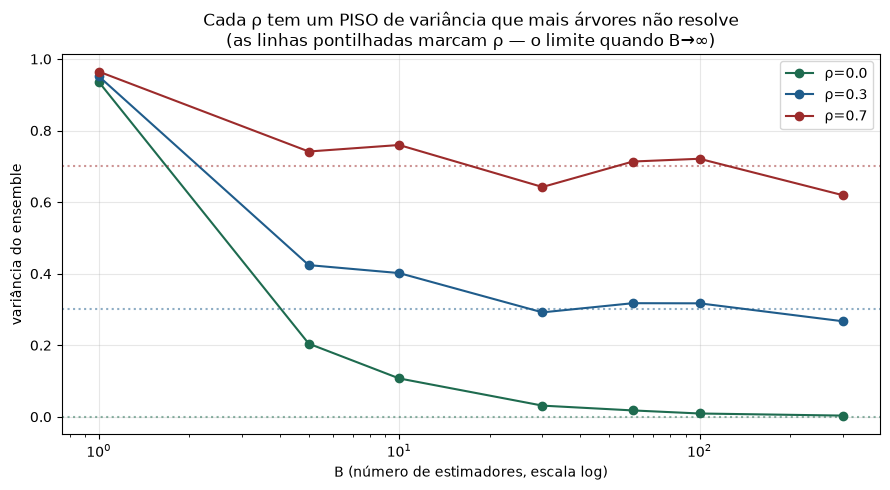

In [5]:
def simula_ensemble_com_correlacao(rho_alvo, n_estimadores_lista, sigma2=1.0,
                                   n_repeticoes=500, seed=0):
    """Simula estimadores correlacionados artificialmente via um fator comum,
    para isolar o efeito de rho na fórmula do teoria.pdf."""
    rng_local = np.random.default_rng(seed)
    resultados = []
    for B in n_estimadores_lista:
        variancias_medias = []
        for _ in range(n_repeticoes):
            fator_comum = rng_local.normal(0, np.sqrt(rho_alvo * sigma2))
            ruido_independente = rng_local.normal(
                0, np.sqrt((1 - rho_alvo) * sigma2), B)
            estimadores = fator_comum + ruido_independente
            variancias_medias.append(estimadores.mean())
        resultados.append(np.var(variancias_medias))
    return np.array(resultados)


n_estimadores_lista = [1, 5, 10, 30, 60, 100, 300]
fig, ax = plt.subplots(figsize=(9, 5))
for rho, cor in [(0.0, VERDE), (0.3, AZUL), (0.7, VERMELHO)]:
    variancias = simula_ensemble_com_correlacao(rho, n_estimadores_lista)
    ax.plot(n_estimadores_lista, variancias, "o-", color=cor, label=f"ρ={rho}")
    ax.axhline(rho, color=cor, ls=":", alpha=0.5)
ax.set_xscale("log")
ax.set_xlabel("B (número de estimadores, escala log)")
ax.set_ylabel("variância do ensemble")
ax.set_title("Cada ρ tem um PISO de variância que mais árvores não resolve\n"
             "(as linhas pontilhadas marcam ρ — o limite quando B→∞)")
ax.legend(); plt.tight_layout(); plt.show()

**A lição central do módulo, isolada matematicamente:** com $\rho=0{,}7$,
a variância do ensemble nunca cai abaixo de ~0,7, não importa quantos
estimadores sejam adicionados. Só reduzir a correlação entre eles (o que
Random Forest faz, no próximo notebook) rompe esse piso.

## O que levar deste notebook

- Bagging reduz variância mantendo o viés praticamente inalterado — o
  ganho de erro total vem quase inteiramente de estabilizar a previsão.
- A redução de variância tem um limite matemático imposto pela correlação
  entre os estimadores — mais árvores sozinhas não superam esse limite.
- Esse limite é exatamente o problema que o Random Forest ataca
  diretamente, como o próximo notebook mostra.

→ Próximo: **Random Forest**, adicionando subamostragem de features para
reduzir a correlação entre árvores.